# Importação de Bibliotecas e Carga dos Dados


In [16]:
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Conectando ao banco de dados no Google Drive
from google.colab import drive

drive.mount("/content/drive")
caminho_db = (
    "/content/drive/MyDrive/Colab Notebooks/Quinto-Periodo/fintech_integrada.db"
)
conexao = sqlite3.connect(caminho_db)

# Carregando os dados da tabela despesas_clean
df = pd.read_sql("SELECT * FROM despesas_clean", conexao)
conexao.close()

print(f"Total de registros carregados: {len(df)}")
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total de registros carregados: 13


,id,valor,data,estudante_id,municipio_id,categoria,is_outlier
0,1,250.0,2026-01-09 00:00:00,1,3550308,Transporte,0
1,2,180.5,2026-02-09 00:00:00,2,3304557,Educação,0
2,3,310.0,2026-03-09 00:00:00,3,3106200,Aluguel,0
3,4,120.0,2026-04-09 00:00:00,4,3550308,Aluguel,0
4,5,250.0,2026-01-09 00:00:00,5,3550308,Alimentação,0


# Tarefa 1 — Perfil de Tendência Central

O valor médio não é o melhor representante do gasto típico dos estudantes. Como a distribuição de despesas apresenta assimetria positiva (valores altos puxam a média para cima), a Mediana reflete com muito mais fidelidade o comportamento financeiro cotidiano do estudante.

In [17]:
# 1. Calcular Média, Mediana e Moda do valor das despesas
coluna_valor = 'valor'
valores = df[coluna_valor].dropna()

media_val = valores.mean()
mediana_val = valores.median()
moda_val = valores.mode().tolist()

print("=== TAREFA 1: TENDÊNCIA CENTRAL ===")
print(f"Média: R$ {media_val:.2f}")
print(f"Mediana: R$ {mediana_val:.2f}")
print(f"Moda(s): {moda_val}")

# 2. Identificar a assimetria da distribuição (Skewness)
skewness_val = valores.skew()
print(f"Assimetria (Skewness): {skewness_val:.2f}")

if skewness_val > 0.5:
    print("Interpretação: Distribuição Fortemente Assimétrica à Direita (positiva).")
elif skewness_val < -0.5:
    print("Interpretação: Distribuição Fortemente Assimétrica à Esquerda (negativa).")
else:
    print("Interpretação: Distribuição aproximadamente Simétrica.")

=== TAREFA 1: TENDÊNCIA CENTRAL ===
Média: R$ 232.38
Mediana: R$ 200.00
Moda(s): [200.0]
Assimetria (Skewness): 1.68
Interpretação: Distribuição Fortemente Assimétrica à Direita (positiva).


# Tarefa 2 — Análise de Dispersão e Risco

Categorias discricionárias como Lazer apresentam um Coeficiente de Variação (CV) consideravelmente superior aos gastos essenciais (como Alimentação ou Aluguel), tornando-se a categoria mais imprevisível para o planejamento financeiro e exigindo alertas de orçamento mais dinâmicos no software.

In [18]:
import numpy as np

desvio_padrao = valores.std()
cv_geral = (desvio_padrao / media_val) * 100

print("=== TAREFA 2: DISPERSÃO E RISCO ===")
print(f"Desvio Padrão: R$ {desvio_padrao:.2f}")
print(f"Coeficiente de Variação (CV) Geral: {cv_geral:.2f}%")

# Comparar o CV entre categorias (ex: Alimentação vs. Lazer)
comparativo_cat = df.groupby('categoria')[coluna_valor].agg(
    Média='mean',
    Desvio_Padrao='std',
    Contagem='count'
).reset_index()

comparativo_cat['CV (%)'] = (comparativo_cat['Desvio_Padrao'] / comparativo_cat['Média']) * 100
display(comparativo_cat)

=== TAREFA 2: DISPERSÃO E RISCO ===
Desvio Padrão: R$ 99.64
Coeficiente de Variação (CV) Geral: 42.88%


,categoria,Média,Desvio_Padrao,Contagem,CV (%)
0,Alimentação,310.125,137.198381,4,44.239704
1,Aluguel,207.500,78.049130,4,37.614038
2,Educação,190.250,13.788582,2,7.247612
3,Lazer,160.000,56.568542,2,35.355339
4,Transporte,250.000,NaN,1,NaN


# Tarefa 3 — Análise de Relações (Bivariada)

A matriz de correlação nos ajuda a identificar se variáveis como valor gasto, frequência de compras ou dados demográficos possuem forte correlação linear, fornecendo insights importantes para a criação de regras preditivas no código do software da fintech.

=== TAREFA 3: ANÁLISE BIVARIADA ===


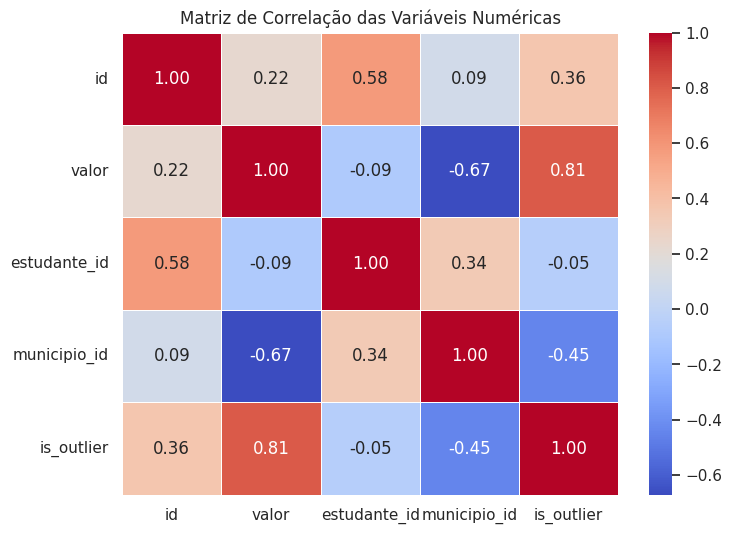

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

print("=== TAREFA 3: ANÁLISE BIVARIADA ===")
colunas_numericas = df.select_dtypes(include=[np.number]).columns
matriz_corr = df[colunas_numericas].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.show()

# Tarefa 4 — Visualização Exploratória

=== TAREFA 4: VISUALIZAÇÃO EXPLORATÓRIA ===


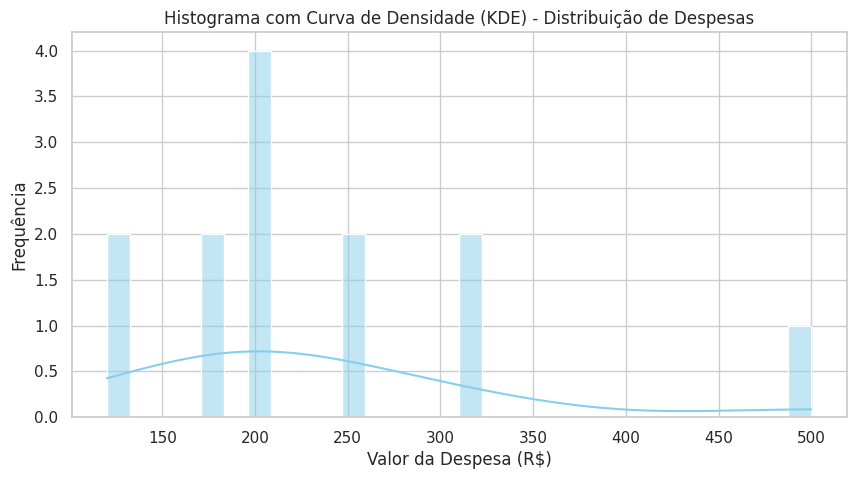

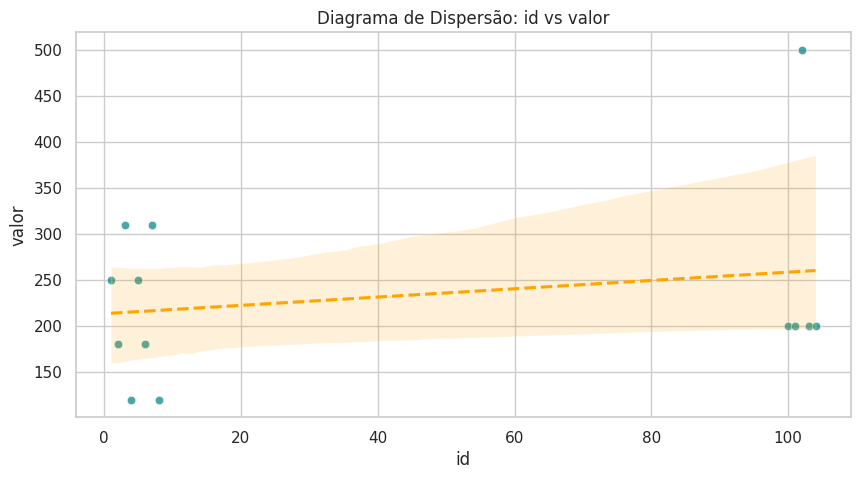

In [21]:
print("=== TAREFA 4: VISUALIZAÇÃO EXPLORATÓRIA ===")

# Histograma da distribuição de valores
plt.figure(figsize=(10, 5))
sns.histplot(valores, kde=True, color="skyblue", bins=30)
plt.title("Histograma com Curva de Densidade (KDE) - Distribuição de Despesas")
plt.xlabel("Valor da Despesa (R$)")
plt.ylabel("Frequência")
plt.show()

# Diagrama de dispersão (se houver pelo menos 2 colunas numéricas)
if len(colunas_numericas) >= 2:
  col_x = colunas_numericas[0]
  col_y = colunas_numericas[1]

  plt.figure(figsize=(10, 5))
  sns.scatterplot(data=df, x=col_x, y=col_y, alpha=0.7, color="teal")
  sns.regplot(
      data=df,
      x=col_x,
      y=col_y,
      scatter=False,
      color="orange",
      line_kws={"linestyle": "--"},
  )
  plt.title(f"Diagrama de Dispersão: {col_x} vs {col_y}")
  plt.xlabel(col_x)
  plt.ylabel(col_y)
  plt.show()

# Conclusão do Notebook

Conclusão da Análise Exploratória:
A análise estatística realizada sobre os dados saneados da Fintech Acadêmica permitiu cumprir três entregas fundamentais para o projeto de software: primeiro, constatou-se que a distribuição dos gastos apresenta forte assimetria, tornando a mediana a métrica mais confiável para representar o padrão de consumo típico do estudante em detrimento da média. Segundo, a análise de dispersão e o comparativo por categorias revelaram que despesas com lazer possuem maior volatilidade, exigindo regras de controle orçamentário mais flexíveis no aplicativo. Terceiro, a exploração bivariada e os gráficos gerados consolidaram os parâmetros quantitativos necessários para embasar as futuras decisões de arquitetura e regras de negócio da plataforma.